In [2]:
# Install core packages
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install biopython
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install shap lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 20.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 34.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 54.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 71.2 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.8 MB/s eta 0:00:00ta 0:00:01
  Installing build depe

In [1]:
import tarfile
import os

In [2]:
# Path to tar file
tar_path = "/home/stu4/s2/sr7788/capstone/mane_overlap_v4.tar"
extract_path = "mane_data"

In [3]:
print("Current working directory:", os.getcwd())
print("Folders in the current directory:")
print(os.listdir("."))

Current working directory: /home/stu4/s2/sr7788/capstone
Folders in the current directory:
['__pycache__', 'ten_percent_graphs', 'mane_data', 'hybrid_model.py', 'batch_process_structures.py', 'ten_percent_voxels', 'process_10percent.py', 'final_merged_dataset.csv', 'train_split.csv', 'final_train_top100_GO_encoded.csv', 'parse_structures.py', 'ten_percent_protein_index.csv', 'uniprot_go_terms.csv', 'final_train_dataset.csv', 'mane_overlap_v4.tar', 'test_split.csv', 'protein_dataset.py', 'train.py', 'cleaned_final_dataset.csv', 'code.ipynb', '.ipynb_checkpoints', 'metrics_gnn.csv']


In [ ]:
# Extracting the tar file
with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path)
                   
print(f"Extraction complete. Files are saved in: {extract_path}")

In [4]:
# List extracted files
extracted_files = os.listdir(extract_path)
print(f"Extracted {len(extracted_files)} files. Sample files: {extracted_files[:10]}")

Extracted 34674 files. Sample files: ['AF-A0A024R9Z1-F1-model_v4.pdb', 'AF-O15194-F1-model_v4.pdb', 'AF-A0A126GVA1-F1-model_v4.cif', 'AF-Q13347-F1-model_v4.pdb', 'AF-Q4G0W2-F1-model_v4.cif', 'AF-Q8TCU6-F1-model_v4.pdb', 'AF-P0DP73-F1-model_v4.pdb', 'AF-P14406-F1-model_v4.cif', 'AF-Q6ZMY9-F1-model_v4.cif', 'AF-O95210-F1-model_v4.cif']


In [8]:
import gzip
import shutil

# List of all .gz files
gz_files = [f for f in os.listdir(extract_path) if f.endswith(".gz")]

print(f"Found {len(gz_files)} compressed files. Decompressing...")

Found 1045 compressed files. Decompressing...


In [9]:
for gz_file in gz_files:
    gz_file_path = os.path.join(extract_path, gz_file)
    decompressed_file_path = gz_file_path.replace(".gz", "")  # Remove .gz extension
    
    # Decompress
    with gzip.open(gz_file_path, 'rb') as f_in:
        with open(decompressed_file_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    
    # Optional: Remove original .gz file after extraction
    os.remove(gz_file_path)

print("Decompression complete.")

Decompression complete.


In [5]:
# List all PDB and CIF files
pdb_files = [f for f in os.listdir(extract_path) if f.endswith(".pdb")]
cif_files = [f for f in os.listdir(extract_path) if f.endswith(".cif")]

print(f"Total PDB files: {len(pdb_files)}")
print(f"Total CIF files: {len(cif_files)}")

Total PDB files: 17334
Total CIF files: 17334


#### PDB Format (.pdb) is widely used and supported by visualization tools & deep learning models.
#### CIF Format (.cif) is newer and preferred for large macromolecular structures only if you need additional metadata.

In [15]:
!python process_10percent.py

[INFO] Total PDB files found: 17334
[INFO] Processing 10% subset: 1733 files
Processing 10% Subset PDB files: 100%|███| 1733/1733 [12:55:34<00:00, 26.85s/it]
[INFO] Subset processing complete. Index saved to: ten_percent_protein_index.csv


In [5]:
import os
import pandas as pd

# Paths
index_file = "ten_percent_protein_index.csv"
graph_dir = "ten_percent_graphs"
voxel_dir = "ten_percent_voxels"

# Load index
df = pd.read_csv(index_file)

# Counters
missing_graphs = []
missing_voxels = []

for i, row in df.iterrows():
    graph_path = row['graph_path']
    voxel_path = row['voxel_path']

    if not os.path.isfile(graph_path):
        missing_graphs.append(graph_path)

    if not os.path.isfile(voxel_path):
        missing_voxels.append(voxel_path)

print(f"\n Total entries in index: {len(df)}")
print(f"Graph files present: {len(os.listdir(graph_dir))}")
print(f"Voxel files present: {len(os.listdir(voxel_dir))}")


 Total entries in index: 1733
Graph files present: 1734
Voxel files present: 1733


In [7]:
import os

csv_files = [f for f in os.listdir("mane_data") if f.endswith(".csv")]

if csv_files:
    print(f"Found {len(csv_files)} CSV files in 'mane_data/':")
    for file in csv_files:
        print(" └──", file)
else:
    print("No CSV files found in 'mane_data/' folder.")

Found 2 CSV files in 'mane_data/':
 └── missing.csv
 └── refseq_prot_to_alphafold.csv


In [8]:
import pandas as pd
import os

csv_folder = "mane_data"

csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

for file in csv_files:
    file_path = os.path.join(csv_folder, file)
    print(f"\n📄 Preview of: {file}\n{'-'*40}")
    try:
        df = pd.read_csv(file_path)
        print(df.head(10))  # Show first 10 rows
        print(f"\nColumns in {file}:", df.columns.tolist())
        print(f"Total rows: {len(df)}")
    except Exception as e:
        print(f"Could not read {file}: {e}")


📄 Preview of: missing.csv
----------------------------------------
      refseq_prot uniprot_accession(s) uniprot_isoform(s)
0     NP_001597.2               Q9BZC7           Q9BZC7-3
1     NP_942131.1               Q13085           Q13085-4
2     NP_899233.1               Q16515           Q16515-2
3     NP_004026.2               Q15067           Q15067-2
4  NP_001123476.1               P12814           P12814-3
5     NP_001103.1               P78563           P78563-2
6  NP_001095940.1               P28332           P28332-2
7     NP_000675.1                  NaN                NaN
8     NP_570603.2               O95782           O95782-2
9     NP_001118.3               Q10567                NaN

Columns in missing.csv: ['refseq_prot', 'uniprot_accession(s)', 'uniprot_isoform(s)']
Total rows: 1635

📄 Preview of: refseq_prot_to_alphafold.csv
----------------------------------------
   refseq_prot         alphafold uniprot_accession
0  NP_001079.1      AF-F1T0I5-F1            F1T0I5
1  

In [11]:
import pandas as pd

# Load both CSVs
df_index = pd.read_csv("ten_percent_protein_index.csv")
df_map = pd.read_csv("mane_data/refseq_prot_to_alphafold.csv")

# Remove any trailing suffix from protein_id if needed
df_index['alphafold'] = df_index['protein_id'].str.replace("-model_v4", "", regex=False)

# Merge on alphafold ID
df_merged = df_index.merge(df_map, on="alphafold", how="left")

# Save final merged dataset
df_merged.to_csv("final_merged_dataset.csv", index=False)
print(" Merged dataset saved as 'final_merged_dataset.csv'")

 Merged dataset saved as 'final_merged_dataset.csv'


In [9]:
import pandas as pd

# Load the dataset
df = pd.read_csv("final_merged_dataset.csv")

# Step 1: Replace uniprot_accession starting with 'A0A' → string "NaN"
df['uniprot_accession'] = df['uniprot_accession'].apply(
    lambda x: "NaN" if isinstance(x, str) and x.startswith("A0A") else x
)

# Step 2: Drop unwanted columns
df.drop(columns=['alphafold', 'refseq_prot'], inplace=True)

# Step 3: Save the cleaned dataset
df.to_csv("cleaned_final_dataset.csv", index=False)
print(" Cleaned dataset with string 'NaN' saved as 'cleaned_final_dataset.csv'")

 Cleaned dataset with string 'NaN' saved as 'cleaned_final_dataset.csv'


In [9]:
print("\n Null Summary Report:")
print("Real NaNs:\n", df.isna().sum())
print("\nString 'NaN' in uniprot_accession column:", (df['uniprot_accession'] == "NaN").sum())


 Null Summary Report:
Real NaNs:
 refseq_prot          0
alphafold            0
uniprot_accession    0
dtype: int64

String 'NaN' in uniprot_accession column: 0


In [62]:
import pandas as pd

# Load your dataset
df = pd.read_csv("cleaned_final_dataset.csv")

# Remove rows where uniprot_accession is NaN (missing)
df_cleaned = df.dropna(subset=['uniprot_accession'])

# Save the cleaned version
df_cleaned.to_csv("final_train_dataset.csv", index=False)
print(f" Cleaned dataset saved as 'final_train_dataset.csv'")
print(f" Final row count after removing nulls: {len(df_cleaned)}")

 Cleaned dataset saved as 'final_train_dataset.csv'
 Final row count after removing nulls: 1419


In [4]:
import requests

uniprot_id = "Q13347"
url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"

response = requests.get(url)
data = response.json()

function_text = ""

# Extract FUNCTION comment from comments section
for comment in data.get("comments", []):
    if comment.get("commentType") == "FUNCTION":
        function_text = comment["texts"][0]["value"]
        break

print("FUNCTION Description:", function_text)

FUNCTION Description: Component of the eukaryotic translation initiation factor 3 (eIF-3) complex, which is required for several steps in the initiation of protein synthesis (PubMed:17581632, PubMed:25849773, PubMed:27462815). The eIF-3 complex associates with the 40S ribosome and facilitates the recruitment of eIF-1, eIF-1A, eIF-2:GTP:methionyl-tRNAi and eIF-5 to form the 43S pre-initiation complex (43S PIC). The eIF-3 complex stimulates mRNA recruitment to the 43S PIC and scanning of the mRNA for AUG recognition. The eIF-3 complex is also required for disassembly and recycling of post-termination ribosomal complexes and subsequently prevents premature joining of the 40S and 60S ribosomal subunits prior to initiation (PubMed:17581632). The eIF-3 complex specifically targets and initiates translation of a subset of mRNAs involved in cell proliferation, including cell cycling, differentiation and apoptosis, and uses different modes of RNA stem-loop binding to exert either translational 

In [63]:
import pandas as pd
import requests
from tqdm import tqdm

df = pd.read_csv("final_train_dataset.csv")
accessions = df['uniprot_accession'].dropna().unique()

def fetch_go_terms(accession):
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            go_terms = [dbref.get("id") for dbref in data.get("uniProtKBCrossReferences", []) if dbref.get("database") == "GO"]
            return go_terms
        else:
            return []
    except:
        return []

go_mapping = {}
for acc in tqdm(accessions):
    go_mapping[acc] = fetch_go_terms(acc)

go_df = pd.DataFrame([
    {"uniprot_accession": acc, "go_terms": ";".join(go_mapping[acc])} for acc in go_mapping
])
go_df.to_csv("uniprot_go_terms.csv", index=False)

100%|█████████████████████████████████████| 1406/1406 [2:07:43<00:00,  5.45s/it]


# Training

In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv("final_train_top100_GO_encoded.csv")

# Explicitly convert column index to a list
columns = list(df.columns)

# Remove the first column if it's the UniProt accession
label_cols = columns[1:] if 'uniprot_accession' in columns else columns

# Convert label columns to numeric just in case, and sum
df[label_cols] = df[label_cols].apply(pd.to_numeric, errors='coerce')

# Now calculate label count per protein
num_labels_per_protein = df[label_cols].sum(axis=1)

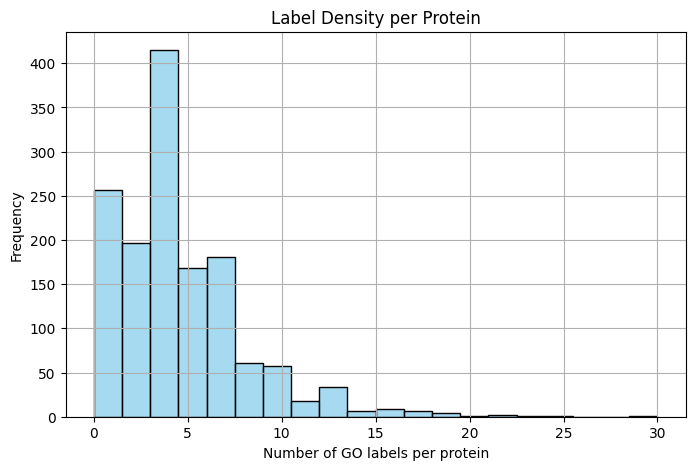

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(num_labels_per_protein, bins=20, kde=False, color='skyblue')
plt.xlabel("Number of GO labels per protein")
plt.ylabel("Frequency")
plt.title("Label Density per Protein")
plt.grid(True)
plt.show()

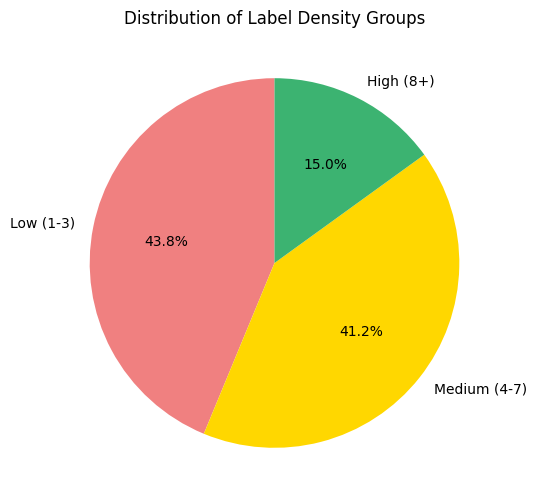

In [12]:
bins = [0, 3, 7, 100]  # You can tune these ranges
labels = ['Low (1-3)', 'Medium (4-7)', 'High (8+)']
groups = pd.cut(num_labels_per_protein, bins=bins, labels=labels)

plt.figure(figsize=(6, 6))
groups.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'gold', 'mediumseagreen'])
plt.title("Distribution of Label Density Groups")
plt.ylabel('')
plt.show()

In [13]:
import pandas as pd

df = pd.read_csv("final_train_top100_GO_encoded.csv")

# If the first few columns are not labels (like protein_id, paths), skip them
# Assuming labels start from column index 4 (adjust this based on your file)
label_cols = df.columns[4:]

num_classes = len(label_cols)
print("Number of GO label classes:", num_classes)

Number of GO label classes: 100


In [14]:
print("Number of classes:", len(label_cols))
print("Example label columns:", label_cols[:5].tolist())

Number of classes: 100
Example label columns: ['GO:0005634', 'GO:0005829', 'GO:0005886', 'GO:0005737', 'GO:0005654']


In [39]:
import numpy as np
# Assuming the label columns start after 'uniprot_accession'
label_cols = df.columns[4:]  # Check if this starts from the correct label column

# OR more robust: select all columns that start with "GO:"
label_cols = [col for col in df.columns if col.startswith("GO:")]

label_matrix = df[label_cols].values.astype(np.float32)

print("Label columns:", label_cols)
print("Number of classes:", len(label_cols))

Label columns: ['GO:0005634', 'GO:0005829', 'GO:0005886', 'GO:0005737', 'GO:0005654', 'GO:0016020', 'GO:0046872', 'GO:0005615', 'GO:0070062', 'GO:0005576', 'GO:0005739', 'GO:0042802', 'GO:0006357', 'GO:0003723', 'GO:0005524', 'GO:0000981', 'GO:0005783', 'GO:0005794', 'GO:0000785', 'GO:0005789', 'GO:0000978', 'GO:0045944', 'GO:0003677', 'GO:0007165', 'GO:0000122', 'GO:0005730', 'GO:0043231', 'GO:0005509', 'GO:0042803', 'GO:0000139', 'GO:0008270', 'GO:0098978', 'GO:0009986', 'GO:0030154', 'GO:0032991', 'GO:0045087', 'GO:0005813', 'GO:1990837', 'GO:0005759', 'GO:0045893', 'GO:0048471', 'GO:0006355', 'GO:0009897', 'GO:0005102', 'GO:0006508', 'GO:0003682', 'GO:0045892', 'GO:0016567', 'GO:0001228', 'GO:0003700', 'GO:0007155', 'GO:0005743', 'GO:0044877', 'GO:0000977', 'GO:0006955', 'GO:0008285', 'GO:0043066', 'GO:0005925', 'GO:0004930', 'GO:0051301', 'GO:0005856', 'GO:0006974', 'GO:0019901', 'GO:0006954', 'GO:0008284', 'GO:0016324', 'GO:0005525', 'GO:0030425', 'GO:0035556', 'GO:0016607', 'GO:

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, hamming_loss
import pandas as pd
import csv
from protein_dataset import ProteinDataset
from hybrid_model import GNNEncoder, CNN3DEncoder, GNN_CNN_Fusion
import time

In [41]:
# Load dataset
df = pd.read_csv("final_train_top100_GO_encoded.csv")

# Get GO term label columns
label_cols = df.columns[4:]  # or filter using: [col for col in df.columns if col.startswith("GO:")]

# Train-test split
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)



In [42]:
from torch_geometric.loader import DataLoader

# 4. Create dataset
from protein_dataset import ProteinDataset
train_dataset = ProteinDataset(df_train, label_columns=label_cols)
test_dataset = ProteinDataset(df_test, label_columns=label_cols)

# 5. Create DataLoaders
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [43]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "17"

In [44]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [45]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

In [46]:
# GNN-only Wrapper 
class GNNModel(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.encoder = GNNEncoder()
        self.classifier = nn.Linear(128, out_dim)

    def forward(self, graph, *_):
        x, edge_index, batch = graph.x, graph.edge_index, graph.batch
        x = self.encoder(x, edge_index, batch)
        return self.classifier(x)


In [47]:
# CNN-only Wrapper
class CNNModel(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.encoder = CNN3DEncoder()
        self.classifier = nn.Linear(128, out_dim)

    def forward(self, _, voxel, *__):
        x = self.encoder(voxel)
        return self.classifier(x)

In [48]:
# Initialize models
gnn_model = GNNModel(out_dim=num_classes).to(device)
cnn_model = CNNModel(out_dim=num_classes).to(device)
hybrid_model = GNN_CNN_Fusion(num_classes=num_classes).to(device)


In [49]:
# Optimizers
gnn_optimizer = torch.optim.Adam(gnn_model.parameters(), lr=1e-3)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
hybrid_optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=1e-3)

In [50]:
# Train Function
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, (graph, voxel, labels) in enumerate(loader):
        graph = graph.to(device)
        voxel = voxel.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(graph, voxel)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    end_time = time.time()
    epoch_loss = total_loss / len(loader)
    print(f"Epoch finished | Loss: {epoch_loss:.4f} | Time taken: {end_time - start_time:.2f} sec")
    return epoch_loss

In [51]:
# Evaluation Function
def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for graph, voxel, labels in dataloader:
            graph = graph.to(device)
            voxel = voxel.to(device)
            labels = labels.to(device)

            outputs = model(graph, voxel)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    auroc = roc_auc_score(all_labels, all_preds, average='macro')
    hamming = hamming_loss(all_labels, all_preds)
    return micro_f1, auroc, hamming


In [52]:
# Training Loop
def run_training(model, loader, optimizer, name, epochs=50):
    print(f"Starting training for {name} model with {epochs} epochs...")
    metrics = []

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")
        train_loss = train(model, loader, optimizer, criterion, device)
        f1, auroc, hamming = evaluate_model(model, test_loader, device)
        metrics.append({"epoch": epoch, "loss": train_loss, "f1": f1, "auroc": auroc, "hamming": hamming})
        print(f"{name} Epoch {epoch}: F1={f1:.4f}, AUROC={auroc:.4f}, Hamming Loss={hamming:.4f}")

    # Save metrics to CSV
    keys = metrics[0].keys()
    with open(f"metrics_{name.lower()}.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(metrics)
    print(f"Training complete for {name}! Metrics saved to metrics_{name.lower()}.csv")


In [53]:
import warnings
warnings.filterwarnings("ignore")

In [54]:
# Run all models
run_training(gnn_model, train_loader, gnn_optimizer, "GNN")

Starting training for GNN model with 50 epochs...

Epoch 1/50
Epoch finished | Loss: 0.5069 | Time taken: 9.24 sec
GNN Epoch 1: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 2/50
Epoch finished | Loss: 0.1682 | Time taken: 10.17 sec
GNN Epoch 2: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 3/50
Epoch finished | Loss: 0.1593 | Time taken: 9.80 sec
GNN Epoch 3: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 4/50
Epoch finished | Loss: 0.1589 | Time taken: 9.78 sec
GNN Epoch 4: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 5/50
Epoch finished | Loss: 0.1599 | Time taken: 9.24 sec
GNN Epoch 5: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 6/50
Epoch finished | Loss: 0.1596 | Time taken: 11.36 sec
GNN Epoch 6: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 7/50
Epoch finished | Loss: 0.1595 | Time taken: 9.59 sec
GNN Epoch 7: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 8/50
Epoch finished | Loss: 0.1596 | Time taken: 9.39 sec
GNN Epoch 8: F1=0.0000

In [55]:
run_training(cnn_model, train_loader, cnn_optimizer, "CNN")

Starting training for CNN model with 50 epochs...

Epoch 1/50
Epoch finished | Loss: 0.2040 | Time taken: 5.29 sec
CNN Epoch 1: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 2/50
Epoch finished | Loss: 0.1637 | Time taken: 5.98 sec
CNN Epoch 2: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 3/50
Epoch finished | Loss: 0.1624 | Time taken: 5.27 sec
CNN Epoch 3: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 4/50
Epoch finished | Loss: 0.1616 | Time taken: 5.66 sec
CNN Epoch 4: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 5/50
Epoch finished | Loss: 0.1615 | Time taken: 6.12 sec
CNN Epoch 5: F1=0.0114, AUROC=0.5004, Hamming Loss=0.0428

Epoch 6/50
Epoch finished | Loss: 0.1571 | Time taken: 5.38 sec
CNN Epoch 6: F1=0.0301, AUROC=0.5007, Hamming Loss=0.0431

Epoch 7/50
Epoch finished | Loss: 0.1490 | Time taken: 6.08 sec
CNN Epoch 7: F1=0.0673, AUROC=0.5019, Hamming Loss=0.0449

Epoch 8/50
Epoch finished | Loss: 0.1376 | Time taken: 5.20 sec
CNN Epoch 8: F1=0.1090, 

In [56]:
run_training(hybrid_model, train_loader, hybrid_optimizer, "Hybrid")

Starting training for Hybrid model with 50 epochs...

Epoch 1/50
Epoch finished | Loss: 0.2363 | Time taken: 11.50 sec
Hybrid Epoch 1: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 2/50
Epoch finished | Loss: 0.1682 | Time taken: 10.99 sec
Hybrid Epoch 2: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 3/50
Epoch finished | Loss: 0.1657 | Time taken: 10.69 sec
Hybrid Epoch 3: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 4/50
Epoch finished | Loss: 0.1650 | Time taken: 12.16 sec
Hybrid Epoch 4: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 5/50
Epoch finished | Loss: 0.1653 | Time taken: 11.72 sec
Hybrid Epoch 5: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 6/50
Epoch finished | Loss: 0.1623 | Time taken: 12.79 sec
Hybrid Epoch 6: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 7/50
Epoch finished | Loss: 0.1619 | Time taken: 11.49 sec
Hybrid Epoch 7: F1=0.0000, AUROC=0.5000, Hamming Loss=0.0428

Epoch 8/50
Epoch finished | Loss: 0.1619 | Time taken: 10

In [57]:
import torch
from sklearn.metrics import f1_score, roc_auc_score, hamming_loss, average_precision_score, label_ranking_loss

def test_model(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for graph, voxel, labels in dataloader:
            graph = graph.to(device)
            voxel = voxel.to(device)
            labels = labels.to(device)

            outputs = model(graph, voxel)
            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).float()

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Metrics
    micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    auroc = roc_auc_score(all_labels, all_probs, average='macro')
    hamming = hamming_loss(all_labels, all_preds)
    avg_precision = average_precision_score(all_labels, all_probs, average='macro')
    rank_loss = label_ranking_loss(all_labels, all_probs)

    print(f"Test Results:")
    print(f"Micro F1-Score       : {micro_f1:.4f}")
    print(f"AUROC (macro)        : {auroc:.4f}")
    print(f"Hamming Loss         : {hamming:.4f}")
    print(f"Average Precision    : {avg_precision:.4f}")
    print(f"Label Ranking Loss   : {rank_loss:.4f}")

    return {
        "F1": micro_f1,
        "AUROC": auroc,
        "Hamming Loss": hamming,
        "Average Precision": avg_precision,
        "Ranking Loss": rank_loss
    }

In [58]:
gnn_test_results = test_model(gnn_model, test_loader, device)
cnn_test_results = test_model(cnn_model, test_loader, device)
hybrid_test_results = test_model(hybrid_model, test_loader, device)

all_results = pd.DataFrame([
    {"Model": "GNN", **gnn_test_results},
    {"Model": "CNN", **cnn_test_results},
    {"Model": "Hybrid", **hybrid_test_results}
])

all_results.to_csv("final_test_results.csv", index=False)
print("\nTest results saved to final_test_results.csv")

✅ Test Results:
Micro F1-Score       : 0.0000
AUROC (macro)        : 0.5228
Hamming Loss         : 0.0428
Average Precision    : 0.0625
Label Ranking Loss   : 0.2119
✅ Test Results:
Micro F1-Score       : 0.1387
AUROC (macro)        : 0.4618
Hamming Loss         : 0.0599
Average Precision    : 0.0653
Label Ranking Loss   : 0.3284
✅ Test Results:
Micro F1-Score       : 0.1516
AUROC (macro)        : 0.5163
Hamming Loss         : 0.0544
Average Precision    : 0.0833
Label Ranking Loss   : 0.2950

Test results saved to final_test_results.csv
